# 2 Angle Classifier

This notebook should be run after having completed the `1 - usability tagger.ipynb` notebook and the `1 - apply_bintag.ipynb` notebook. These two notebooks are responsible for cleaning up the dataset and help to avoid letting the models learn on images of interior elements, car accesoires, odometers, placeholder images etc...

The goal of this notebook is to predict the angle at which an image is taken and see if this is usefull to finetune models on. The reasoning behind this are visual cues often shared among different models of the same brand: 

e.g. BMW has a few distinctive visual cues in their design language of cars: 
- Frontside: Kidney grill - an element that has been introduced on the BMW 303 in 1933 and has known various redesigns (https://www.bmw.com/en/design/the-bmw-kidney-grille-through-time.html).
- Sideview: Hoffmeister kink - A subtle curve in the C-pillar (not exclusively but predominantly used by BMW: https://en.wikipedia.org/wiki/Hofmeister_kink )

e.g. Volvo:
- Frontside: Thor's hammer headlights: Used in modern cars the DRL's are inspired by Swede's folklore and dubbed the "Thor's Hammer Headlights" (https://www.matthewsvolvosite.com/thors-hammer-headlights/) 

... 

The aim of this notebook is to provide an estimate of the angle at which a picture is taken. In the next phase (Brand Prediction) We'll compare if training models on specific angles are more precise than models trained on all angles at once. The idea is that a model will pick up these visual cues by focussing on only a specific angle more effectively than seeing the whole dataset (this is to be investigated)

Codewise this notebook will focus on implementing new elements that might be needed later: 
1) Out of Core learning: using some kind of batch processing of the image data (Hard requirement for processing 4million images at the brand identification stage)
2) Data augmentation: adding a few functions to add more variance in the data (Hard requirement for predicting low-occuring models e.g. Ford Anglia...)

In [31]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datetime import datetime
import tensorflow as tf
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, cohen_kappa_score
import os
import sys
#import re
# import random
# import uuid
from tqdm import tqdm


sys.path.append('../../utils')
import implot
from configloader import Configloader
from database import Database
import cnn_helpers
import file_io
import style

In [2]:
config = Configloader()

db = Database(config)
db.connect()

basedir = config.get('settings', 'image_directory')
augm = config.get('dir_augmentations', 'subfolder')

Connection established


In [3]:
augment_base = os.path.join(basedir, augm, 'angle phase')

In [4]:
# Utilities that are only needed in the Angle Tagging phase: 
# these are not made available globally as an importable utility.
def augmentate_data(df): 
    """
        Takes a dataframe and returns a list of new rows so that every angle has an equal 
        amount of instances as defined by the INSTANCES constant. 

        parameter: df (pandas dataframe) with angle column

        returns list of rows matching the columns in df
    """
    new_rows = []
    for angle in df.angle.unique():
        relevant_angles = df.query(f'angle=="{angle}"')
        amount_to_augment = INSTANCES - len(relevant_angles)
        for _ in tqdm(range(amount_to_augment)):
            base_image = relevant_angles.sample(1)
            augmented = cnn_helpers.augment(base_image, augment_base)
            new_rows.append(augmented)
    return new_rows

def learn_angle(X, y, validation_split, bbox):
    """I will not make this a reusable component for other learning tasks, this is only for angle learning. 
    Might use other parameters/ model sequences for the actual brand and or model predictions. Since it is limited
    to angle learning, it'll not be made part of the utilities. 

    X = dataframe of training data
    y = dataframe with targets
    note that X and y should be shuffled before passing as arguments.
    validation_split = float (0 to 1). how the data should be split
    bbox = bool

    returns; nothing.
    ouput = model dump per epoch. 
    """
    #Note: I'm comfortable with this way of splitting, remember that the datframe
    # was shuffled at random and that X_train was a perfectly even distributed class.
    # Yes, there will be some inequality, but this is not of any significance. 
    train_data = X[:int(1-validation_split * len(X))]
    val_data = X[int(1-validation_split * len(X)):]
    y_train_data = y[:int(1-validation_split * len(X))]
    y_val_data = y[int(1-validation_split * len(X)):]

    assert(len(train_data)+ len(val_data) == len(X))
    assert(len(y_train_data) ==  len(train_data))

    # Deep learning part here: implement the plateau and early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=6, 
        restore_best_weights=True
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-6, 
        verbose=1
    )
    e = '{epoch:02d}'
    model_checkpoint = ModelCheckpoint(
        filepath=os.path.join(model_dest_dir, f'model_angles-bbox={bbox}-epoch={e}.keras'),
        save_freq=epoch_checkpoint,
        save_best_only=False,
        verbose=0
    )

    # Angle classifier with CNN
    angle_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(shape, shape, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(ANGLES), activation='softmax')
    ])

    angle_model.compile(
        optimizer=Adam(learning_rate=0.001), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )

    #Do just in time preprocessing of the images: yields both the numpy array and targets!
    train_gen = cnn_helpers.image_generator(
        batch_size=batch_size, 
        data_frame=train_data, 
        bboxs=bbox, 
        shape=shape, 
        y_train_encoded=y_train_data
    )

    #Split validation separately
    val_gen = cnn_helpers.image_generator(
        batch_size=batch_size, 
        data_frame=val_data, 
        bboxs=bbox, 
        shape=shape, 
        y_train_encoded=y_val_data
    )

    angle_model.fit(
        train_gen,
        epochs=max_epoch, 
        steps_per_epoch=len(train_data) // batch_size,
        batch_size=batch_size, 
        validation_data=val_gen,
        validation_steps = len(val_data) // batch_size,
        callbacks=[early_stopping, lr_scheduler, model_checkpoint] 
    )
    #Okay, the callback principle is really cool.
    # You just put a bunch of assigned variables in there that are mapped to some part of the KERAS API and it automagically handles everything for you. 

## 2.1 Constants:

In [5]:
#For each tag, how many instances will we shown as part of the training data (AFTER SPLITTING)
INSTANCES = 2500
#Put the angles in order: nicer to work with later on in CM it is structured logically: 
ANGLES = ["front", "frontleft", "left", "rearleft", "rear", "rearright", "right", "frontright"]
#Random state not used: this notebook is ran a few times untill 2.9; varying random state is good in this case.
#RS = 42

## 2.2 Getting tagged data for training purposes:

In [6]:
get_traindata_query = """
    SELECT * 
    FROM angletags
    JOIN images ON images.id = angletags.image_id
    WHERE angletags.angle <> 'crappy'
    """
traindata = db.execute_query(get_traindata_query)
traindf = pd.DataFrame(traindata)
traindf = file_io.make_absolute_path(traindf, basedir, 'image_path', 'abs_path', True)
traindf.sample(10)

,image_id,angle,manual_annotation,pk,id,listing_id,processed,use_image,certainty_of_outside_yolo,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,area,confidence,abs_path
1799,847010,frontleft,1,4612,847010,54291,1,1,None,40.0,57.0,678.0,460.0,0.610312,0.821507,/home/frederic/Documents/automotive_image_data...
1441,107214,frontleft,1,3682,107214,7059,1,1,None,109.0,109.0,587.0,332.0,0.338166,0.931114,/home/frederic/Documents/automotive_image_data...
4246,1050577,frontleft,1,11302,1050577,67722,1,1,None,115.0,98.0,642.0,474.0,0.471094,0.940986,/home/frederic/Documents/automotive_image_data...
2604,1068539,rearleft,1,6788,1068539,68932,1,1,None,54.0,169.0,693.0,460.0,0.440147,0.931620,/home/frederic/Documents/automotive_image_data...
6305,1107388,frontright,1,17006,1107388,71606,1,0,None,NaN,NaN,NaN,NaN,NaN,NaN,/home/frederic/Documents/automotive_image_data...
3534,1525400,frontleft,1,9410,1525400,98546,1,1,None,35.0,49.0,726.0,431.0,0.704039,0.741770,/home/frederic/Documents/automotive_image_data...
5131,998232,rearleft,1,13835,998232,64738,1,1,None,2.0,69.0,750.0,538.0,0.833220,0.909465,/home/frederic/Documents/automotive_image_data...
7162,1058085,frontright,1,19428,1058085,68219,1,1,None,48.0,179.0,370.0,368.0,0.256223,0.950163,/home/frederic/Documents/automotive_image_data...
4290,1506031,rear,1,11439,1506031,97335,1,1,None,196.0,111.0,558.0,406.0,0.337510,0.904083,/home/frederic/Documents/automotive_image_data...
2392,935952,front,1,6204,935952,60531,1,1,None,129.0,32.0,634.0,499.0,0.558872,0.820149,/home/frederic/Documents/automotive_image_data...


In [7]:
traindf.angle.value_counts()

angle
frontleft     1491
frontright    1127
rearright     1058
rearleft      1014
front          906
rear           788
right          493
left           484
Name: count, dtype: int64

There's some class imbalance here (frontleft is over 3 times more prevalent than shots taken from the left). We'll use oversampling techniques on all classes to show the model `INSTANCES` amount of instances per class. In an attempt to improve generalization we'll add small image manipulation methods to an image that is not shown for the first time (e.g. gaussian noice, warping, stretching....) WE DO NOT FLIP OR MIRROR the image, this would mean a different antletag would be needed. (You could for instance flip an image LEFT to RIGHT and then use the other tag, but we'll not be doing this!)

Before augmenting, we need to apply a solid splitting strategy to avoid feature leaking: 

## 2.3 Train test split.
Use a stratified split based on the angle to use 20% of the data as unseen testdata. This is done based on the *angle* label.

In [8]:
#no random state here, will run this notebook a few times
X_train, X_test = train_test_split(traindf, test_size=0.2, stratify=traindf.angle)


In [9]:
assert (len(traindf) == len(X_train) + len(X_test))

`X_test` are not touched for learning; we stash them away and look back to them after training a CNN. NO augmentation will be done on X_test. Notice that we do not have our targets yet. It's a bit easier to work with like this untill I have my classes balanced out using augmentation.

## 2.4 Applying data augmentation and getting balanced classes: 
I'm limited with memory and don't want to have the augmented images in memory. In stead I'll use the SSD (M2 drive - so fast IO) to store these augmented pictures. (Sacrifice some storage, to gain free memory). The overhead is the IO speed of the M2 SSD vs IO speed of RAM - which is a significant penalty, but I can live with this. 

Augmented images will be stored using a UUIDV4 (almost guaranteed to be unique: see pigeonhole principle) so I'm not worried about overwriting data. augmented images will find a nice welcoming home in a dedicated folder that I can send to oblivition after the notebook is done - these are not needed further down the lifecyle of this project.

The content of the `X_test` dataframe will not be augmented, the `X_train` dataframe will be augmented so that all classes are equally present. This will be stored in a new dataframe at the end of section 2.4

In [10]:
#otherwise tf keeps complaining when adding gaussian noise
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-05-04 13:44:13.739781: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 13:44:16.388285: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 13:44:16.388392: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [11]:
file_io.wipe_folder(augment_base)

In [12]:
augmented_rows = augmentate_data(X_train)
augmented_df = pd.concat([X_train, pd.DataFrame(augmented_rows)], axis=0)
augmented_df = cnn_helpers.shuffle_df(augmented_df)

100%|██████████| 2106/2106 [00:27<00:00, 76.66it/s] 


In [13]:
#finally prepare the augmented_df by cating the bbox fields to int and setting nan to sentinel -1
augmented_df = cnn_helpers.cast_bbox_values(augmented_df)

In [14]:
augmented_df.angle.value_counts()
#augmentation was good.

angle
right         2500
frontright    2500
rear          2500
left          2500
rearleft      2500
frontleft     2500
front         2500
rearright     2500
Name: count, dtype: int64

## 2.5 Assigning Train/test variables
I kept my labels part of the dataframe during the data augmentation phase, with that out of hte way, time to go back to standard practice. We'll not be using `train_test_split()` method here as we already have this split done. 

In [15]:
y_train = augmented_df['angle']
X_train = augmented_df.drop(columns=['angle'])
y_test = X_test['angle']
X_test = X_test.drop(columns=['angle'])

## 2.6 Label encoding.
We need to convert the `ANGLES` cosntant to  integer labels. Originally this notebook used `LabelEncoder`, however this does not preserve the order we have in `ANGLES`. This order does make it easier to interpret the confusionmatrix at the end. To overcome this nuissance we use `ordinalencoder`. More info on this issue: https://github.com/scikit-learn/scikit-learn/issues/12086 

In [16]:
angles_nested = [[angle] for angle in ANGLES]
ordinal_encoder = OrdinalEncoder(categories=[ANGLES])
ordinal_encoder.fit(angles_nested)


OrdinalEncoder(categories=[['front', 'frontleft', 'left', 'rearleft', 'rear',
                            'rearright', 'right', 'frontright']])

In [17]:

y_train_encoded = ordinal_encoder.transform([[label] for label in y_train]).flatten().astype('int')
y_test_encoded = ordinal_encoder.transform([[label] for label in y_test]).flatten().astype('int')

## 2.7 Training a CNN
In phase one epochs weren't implemented in an optimal way, apparently you can mid-epoch decide to dump and store the result. Python can also self-monitor how much improvement is made per epoch. So it can early stop. These techniques are part of callbacks API (earlystopping and ModelCheckpoint)
https://machinelearningmastery.com/check-point-deep-learning-models-keras/

These techniques will be used in phase 2

In [18]:
#how large will the image be to train on: If you change it here, whole script is updated
shape = 256

#Use or Not use BBOX? In phase 1 it wasn't worth the effort, what about angle tagging?? 
# I expect it to be useful here as cutting an image of does not make i harder to identify
# and a cut off image does not render it 'invalid' for this task.
bboxs = [True, False]

#At how many epoch(stps) should a dump of the model be made (Checkpoints)
epoch_checkpoint = 5 
#What's the maximum amount of epochs to go over before killing the learing process.
max_epoch = 100

#Batch size
batch_size = 32

#number of classes: 
numclasses = len(ANGLES)

#For online learning we presplit our X_train in a new train and validation set, define ratio here: 
validation_split = 0.2

#where to save (checkpoint iterations of ) the model?
model_dest_dir = os.path.join(os.getcwd(), '..', '..', 'models', 'angle_models')
os.makedirs(model_dest_dir, exist_ok=True)


In [19]:
file_io.wipe_folder(model_dest_dir)
for bbox in bboxs:
    learn_angle(X_train, y_train_encoded, validation_split, bbox)

/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-04 13:47:18.563243: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 13:47:18.563532: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 13:47:18.563633: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but ther

Epoch 1/100


I0000 00:00:1746359240.495392    5016 service.cc:146] XLA service 0x798cfc00d340 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746359240.495433    5016 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 6700 XT, AMDGPU ISA version: gfx1030
2025-05-04 13:47:20.532433: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  1/500 ━━━━━━━━━━━━━━━━━━━━ 2:11:34 16s/step - accuracy: 0.1250 - loss: 2.1006

I0000 00:00:1746359255.386597    5016 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 173s 315ms/step - accuracy: 0.6905 - loss: 1.2192 - val_accuracy: 0.9619 - val_loss: 0.1466 - learning_rate: 0.0010
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.9619 - loss: 0.1396 - val_accuracy: 0.9844 - val_loss: 0.0683 - learning_rate: 0.0010
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 169s 338ms/step - accuracy: 0.9794 - loss: 0.0690 - val_accuracy: 0.9859 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 329ms/step - accuracy: 0.9863 - loss: 0.0447 - val_accuracy: 0.9904 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 326ms/step - accuracy: 0.9891 - loss: 0.0317 - val_accuracy: 0.9889 - val_loss: 0.0471 - learning_rate: 0.0010
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 170s 340ms/step - accuracy: 0.9890 - loss: 0.0380 - val_accuracy: 0.9924 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9

## 2.7 Asserting model performance

Let's process the original testdata of images for each of the eight angles; this batch is small enough to fit in memory, so we run it in a single go. For this we'll be revisiting the variables `X_test` and `y_test` created in step 2.3. 

We have two variants on the same model: one with and one without BoundingBox. The images need to be preprocessed in the same way to assess performance. 

Just out of interest we'll also use non-bound images on the bounded model and vice versa; in total we'll be generating four confusion matrices: 

1) Model With BBOX + Images with BBOX
2) Model without BBOX + Images without BBOX
3) Model With BBOX * Images without BBOX
4) Model without BBOX + Images with BBOX

The two final models are simply the models with the highest Epoch count; one with BBOX to true in the filename and one without. Since epochs are time-sensitively created (epoch 2 is created later than epoch 1); we can simply take the 'most recent created file' for BBOX TRUE and for BBOX FALSE, those are automatically the best models. 

In [20]:
sorted_models = file_io.get_folder_content(model_dest_dir)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


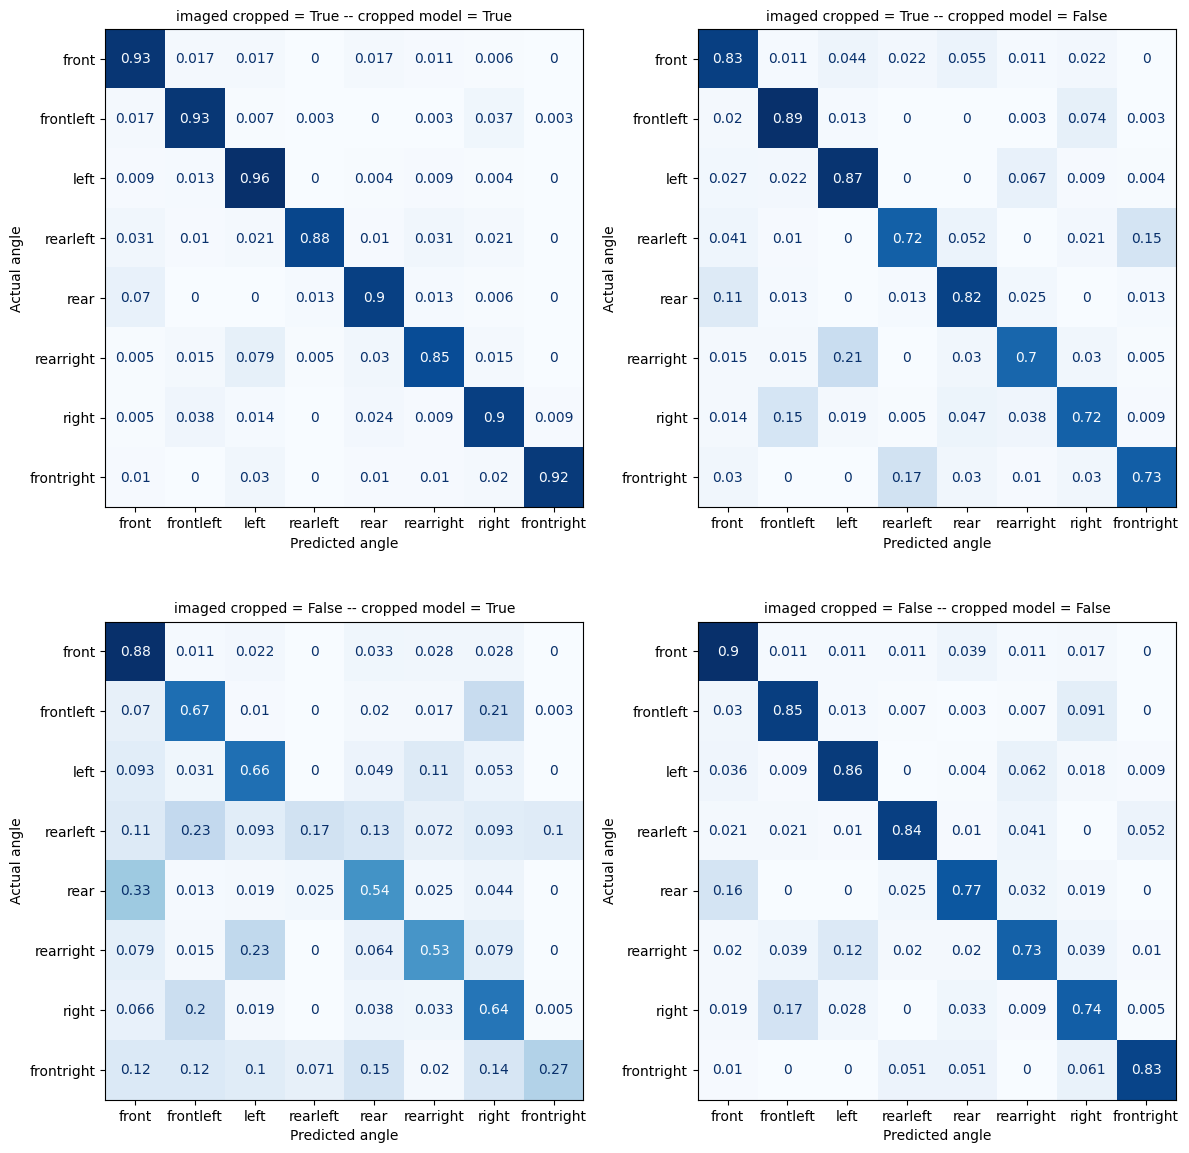

In [28]:
cms = {}
metrics = {}

X_test = cnn_helpers.cast_bbox_values(X_test)
decoded_labels = ordinal_encoder.inverse_transform([[i] for i in range(8)]).flatten()
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()
idx = 0
metrics_dict = {}
for crop_image in bboxs:
    X_test_images = []
    for _, row in X_test.iterrows():
        coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
        image = cnn_helpers.preprocess_image(row['abs_path'], crop_image, coords, shape)
        X_test_images.append(image)
    X_test_images = np.array(X_test_images)
    for use_cropped_model in bboxs:
        title = f"imaged cropped = {crop_image} -- cropped model = {use_cropped_model}"
        matching_models = [f for f in sorted_models if f'bbox={use_cropped_model}-' in f]
        model = load_model(matching_models[-1])
        predicts = model.predict(X_test_images)
        predicts = np.argmax(predicts, axis=1)

        decoded_actuals = ordinal_encoder.inverse_transform(y_test_encoded.reshape(-1, 1)).flatten()
        decoded_predicts = ordinal_encoder.inverse_transform(predicts.reshape(-1, 1)).flatten()

        metrics[title] = implot.quick_metrics(decoded_actuals, decoded_predicts)
        cms[title] = implot.make_cm(decoded_actuals, decoded_predicts, decoded_labels, embed=True)

for ax, (title, cm_disp) in zip(axs, cms.items()):
    cm_disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted angle")
    ax.set_ylabel("Actual angle")
plt.tight_layout()
plt.show()

It's quite apparent that the worst combination of cropping factors is when the image given to predict is not cropped. The best performing model is the model that was trained on the cropped bounding boxes, this means that it was a worthwhile time-investment of generating the boudingboxes with YOLO. 

An interesting observations in the well-performing combinations (although the same can be said for both models and for both prediction scenarios) is that the models most often struggle with opposite views (e.g. Actual = Rear, Predict = Front).

I had expected a peak of false positives surrounding the true positive (e.g. Target = Front; higher error rates expect at frontleft and frontright). This effect is not as pressent as thought.


In [37]:
metrics_shorttitled= {k.replace('True', '1').replace('False', '0').replace('imaged cropped', 'predict').replace('cropped model', 'train'):v for k,v in metrics.items()}

fig = implot.plot_quick_metrics(metrics_shorttitled)
fig.update_layout(
    height=1080,
    width=1920,
    title_text='Cropping vs Not-cropping for angle tagging. 1= cropped; 0 = uncropped.',
    showlegend=False
    
)


The model that seems to perform the best, is a model that is trained on cropped images and where cropped images are provided to predict. The second best is a model where neither training or prediction data is cropped. Hybrid approaches, where either training or prediction data is cropped and the other note seem to score worse.

## 2.8 Deciding on a model and training on full augmented dataset.
There is a clear advantage to using cropped data to learn an cropped data to perform predictions on. The final model to train shall thus use the bounding box data. 

An interesting thought: What would happen if you train an extra model that has padded bounding boxes of 10%? 

## 2.9 Using the fully tagged dataset for training a final model.

In [38]:
#augmentate on the full traindf dataset: 
file_io.wipe_folder(augment_base)
augmented_rows = augmentate_data(traindf)
augmented_df_full = pd.concat([traindf, pd.DataFrame(augmented_rows)], axis=0)


100%|██████████| 2016/2016 [00:25<00:00, 78.19it/s] 


In [39]:
#shuffle the dataset
augmented_df_full = cnn_helpers.shuffle_df(augmented_df_full)
#to ints
augmented_df_full = cnn_helpers.cast_bbox_values(augmented_df_full)

In [40]:
#splitting is handled by the learn_angle function, we don't do it here explicitly but it is being done!
X = augmented_df_full.drop(columns=['angle'])
y_string = augmented_df_full['angle']
y = ordinal_encoder.transform([[label] for label in y_string]).flatten().astype('int')

In [41]:
file_io.wipe_folder(model_dest_dir)#wipe the old models of the partial set and train again. 
bbox = True # we found in 2.7 that having a cropped image was the best for training purposes.
learn_angle(X, y, validation_split, bbox)

/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 259ms/step - accuracy: 0.6315 - loss: 1.4333 - val_accuracy: 0.9352 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 128s 256ms/step - accuracy: 0.9554 - loss: 0.1678 - val_accuracy: 0.9650 - val_loss: 0.1294 - learning_rate: 0.0010
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 125s 251ms/step - accuracy: 0.9741 - loss: 0.0863 - val_accuracy: 0.9660 - val_loss: 0.1493 - learning_rate: 0.0010
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 125s 250ms/step - accuracy: 0.9817 - loss: 0.0626 - val_accuracy: 0.9783 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9871 - loss: 0.0430 - val_accuracy: 0.9814 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - accuracy: 0.9880 - loss: 0.0370 - val_accuracy: 0.9786 - val_loss: 0.1171 - learning_rate: 0.0010
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - a

## 2.10: Exporting both models and their label-encoding.
I don't want to pickle the label-encoder, so I'll opt for a kv-dump to a textfile. 

In [42]:
#we need to store the labels for the predicted numbers
oe_as_dict = cnn_helpers.ordinal_encoder_to_dict(ordinal_encoder)

In [43]:
#where to store all files considered to be ML output for phase 2 (phase 1 has no ouput for the final pipeline)
storage_dir_for_angle_stuff = os.path.join( 
    config.get('directories', 'root_dir'), 
    config.get('directories', 'final_models_dirname'), 
    config.get('directories', 'final_angle_dir')
)
storage_dir_for_angle_stuff

'/home/frederic/Documents/automotive_project/final models/angles'

In [44]:
current_date = datetime.now()
formatted_date = current_date.strftime("%d/%m/%Y")
json_name = 'encoded_labels.json'
keras_name = 'angle_predictor.keras'

In [45]:
#save label encoder kv-pairs to a JSON file
file_io.dict_to_json_file(oe_as_dict, storage_dir_for_angle_stuff, json_name)

In [46]:
#last model gets saved to output folder: 
sorted_models = file_io.get_folder_content(model_dest_dir)
assert len(sorted_models) > 0
last_model = sorted_models[-1]
file_io.copy_model(last_model, storage_dir_for_angle_stuff, keras_name)


In [47]:

message = f"""
    Model generated using notebook 2 - Angle classifier.ipynb

    This model -{keras_name} - is capable of predicting 8 values ranging 0 to 7 inclusife, which match one of the given
    angle labels. These labels are stored in the accompanying {json_name} file. 

    Model dumpdate: {formatted_date}
    Original filename: {last_model}
"""
file_io.write_readme(storage_dir_for_angle_stuff, message)

## 2.11: reclaim space on drive
wipe augmentation data and epoch dumps

In [48]:
file_io.wipe_folder(augment_base)
file_io.wipe_folder(model_dest_dir)

In [49]:
print('Notebook completed, you can now use the two trained model and apply it to your data.')

Notebook completed, you can now use the two trained model and apply it to your data.
